# Transformada de Hough Estándar (SHT)

El principio fundamental es la conversión de puntos de un espacio cartesiano $(x, y)$ a un espacio de parámetros, permitiendo que el problema de detectar una línea se convierta en un problema de encontrar intersecciones en un acumulador.

**El problema de la pendiente infinita:**

En la ecuación de la recta tradicional $y = mx + c$, una línea vertical tiene una pendiente $m$ infinita, lo que impide su representación computacional. Por ello, se utiliza la notación polar:$$\rho = x \cos \theta + y \sin \theta$$

Donde:

- $\rho$ (rho): Es la distancia perpendicular desde el origen hasta la línea.

- $\theta$ (theta): Es el ángulo formado por esa perpendicular con el eje horizontal.

## El Espacio de Parámetros (Hough Space)

- Punto a Sinusoide: 

   Un punto único en la imagen $(x, y)$ se transforma en una curva sinusoidal en el espacio $(\rho, \theta)$.

- Línea a Punto: 

   Si varios puntos en la imagen pertenecen a la misma recta, todas sus sinusoides en el espacio de Hough se cruzarán en un único punto común $(\rho, \theta)$.

**El Sistema de Votación**

Para implementar esto, el algoritmo crea una matriz bidimensional llamada acumulador.

1. Se discretiza el espacio de $(\rho, \theta)$ en celdas.

2. Para cada píxel de borde detectado (por ejemplo, mediante Canny), se calculan todos los posibles valores de $\rho$ para distintos ángulos $\theta$.

3. Se suma un "voto" a cada celda $(\rho, \theta)$ correspondiente.

4. Las celdas con la mayor cantidad de votos representan las líneas más probables de la imagen original.

Para entender todo esto mejor crearemos un lienzo sintético y aplicaremos Hough:

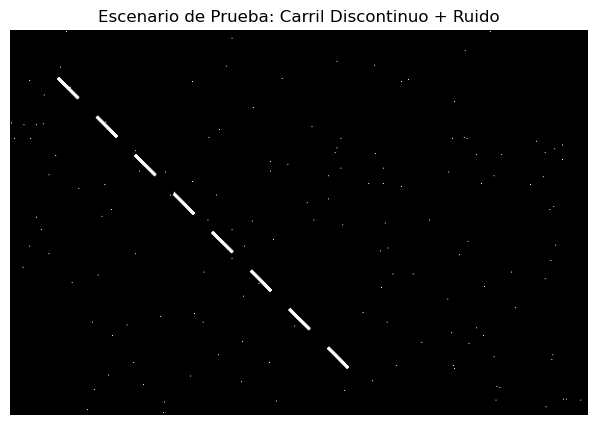

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# 1. Creamos un lienzo negro de 400x600 píxeles
lienzo = np.zeros((400, 600), dtype=np.uint8)

# 2. Dibujamos una línea discontinua (simulando los guiones de un carril)
for i in range(50, 350, 40):
    cv2.line(lienzo, (i, i), (i + 20, i + 20), 255, 2)

# 3. Añadimos ruido aleatorio (simulando reflejos en el asfalto o lluvia)
np.random.seed(42) 
ruido_x = np.random.randint(0, 600, 150)
ruido_y = np.random.randint(0, 400, 150)
lienzo[ruido_y, ruido_x] = 255

# Visualizamos el escenario base
plt.figure(figsize=(8, 5))
plt.imshow(lienzo, cmap='gray')
plt.title("Escenario de Prueba: Carril Discontinuo + Ruido")
plt.axis('off')
plt.show()

In [18]:
# ==========================================
#  STANDART HOUGH TRANSFORM 
# ==========================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

def etapa1_sht_bruta(umbral):
    # Ejecutamos la SHT estándar
    lineas = cv2.HoughLines(lienzo, rho=1, theta=np.pi/180, threshold=umbral)
    
    resultado = cv2.cvtColor(lienzo, cv2.COLOR_GRAY2BGR)
    
    if lineas is not None:
        for i in range(len(lineas)):
            rho, theta = lineas[i][0]
            # Conversión polar a cartesiana para dibujo infinito
            a, b = np.cos(theta), np.sin(theta)
            x0, y0 = a * rho, b * rho
            x1 = int(x0 + 1000 * (-b))
            y1 = int(y0 + 1000 * (a))
            x2 = int(x0 - 1000 * (-b))
            y2 = int(y0 - 1000 * (a))
            
            # Dibujamos en rojo para indicar que es "bruto"
            cv2.line(resultado, (x1, y1), (x2, y2), (255, 0, 0), 1)
            
    plt.figure(figsize=(8, 5))
    plt.imshow(resultado)
    plt.title(f"Etapa 1: SHT Bruta (Líneas detectadas: {len(lineas) if lineas is not None else 0})")
    plt.axis('off')
    plt.show()

widgets.interact(etapa1_sht_bruta, umbral=widgets.IntSlider(min=1, max=100, value=30));

interactive(children=(IntSlider(value=30, description='umbral', min=1), Output()), _dom_classes=('widget-inter…

rho=1 y theta=np.pi/180: Definen la resolución del acumulador en el espacio de Hough.

threshold=20: El número mínimo de "votos" o intersecciones para que un conjunto de puntos se considere una línea.

minLineLength=20: Descarta cualquier segmento más corto de 20 píxeles, eliminando ruidos pequeños.

maxLineGap=300: Permite unir segmentos que están separados por hasta 300 píxeles, lo cual es vital para detectar líneas de carril discontinuas.

Dentro del bucle for, el código calcula la geometría de cada segmento detectado usando las Ecuaciones 15 y 16 del artículo:

- **Pendiente (slope)**: Se calcula como $m = \frac{y_2 - y_1}{x_2 - x_1}$.

- **Intersección (intercept)**: Se calcula como $c = y_1 - m \cdot x_1$.

**Lógica de filtrado:**

- slope < -0.5: Se clasifica como carril izquierdo. En coordenadas de imagen (donde el origen está arriba a la izquierda), una pendiente negativa indica una línea que se inclina hacia la derecha según sube hacia el horizonte.

- slope > 0.5: Se clasifica como carril derecho.Filtro horizontal: Las líneas con pendientes entre -0.5 y 0.5 se ignoran, ya que suelen ser ruidos del horizonte o sombras transversales.

## Lane Line Averaging

La Transformada de Hough suele detectar decenas de pequeños segmentos para un solo carril debido a discontinuidades en la pintura, sombras o texturas del asfalto. Si dibujáramos todos estos segmentos directamente, la visualización sería caótica y el sistema de control del vehículo recibiría señales contradictorias.

In [19]:
#LANE LINE AVERAGING

def etapa2_averaging(umbral):
    lineas = cv2.HoughLines(lienzo, rho=1, theta=np.pi/180, threshold=umbral)
    
    pendientes_izq, interceptos_izq = [], []
    pendientes_der, interceptos_der = [], []
    
    if lineas is not None:
        for i in range(len(lineas)):
            rho, theta = lineas[i][0]
            sin_t, cos_t = np.sin(theta), np.cos(theta)
            if sin_t == 0: continue
            
            # Cálculo de m y c (Eq. 9 y 10)
            m = -cos_t / sin_t
            c = rho / sin_t
            
            # Clasificación por signo de pendiente [cite: 275-276]
            if m < -0.5:
                pendientes_izq.append(m)
                interceptos_izq.append(c)
            elif m > 0.5:
                pendientes_der.append(m)
                interceptos_der.append(c)

    # Dibujo del carril promediado final
    alto, ancho = lienzo.shape
    resultado = cv2.cvtColor(lienzo, cv2.COLOR_GRAY2BGR)
    
    for pends, inters, color in [(pendientes_izq, interceptos_izq, (0, 255, 0)), 
                                 (pendientes_der, interceptos_der, (0, 255, 0))]:
        if pends:
            avg_m, avg_c = np.mean(pends), np.mean(inters) # Promediado [cite: 294]
            y1, y2 = alto, int(alto * 0.6)
            x1, x2 = int((y1 - avg_c) / avg_m), int((y2 - avg_c) / avg_m)
            cv2.line(resultado, (x1, y1), (x2, y2), color, 8)

    plt.figure(figsize=(8, 5))
    plt.imshow(resultado)
    plt.title("Etapa 2: Lane Line Averaging (Resultado Estable)")
    plt.axis('off')
    plt.show()

widgets.interact(etapa2_averaging, umbral=widgets.IntSlider(min=1, max=100, value=30));

interactive(children=(IntSlider(value=30, description='umbral', min=1), Output()), _dom_classes=('widget-inter…

**El Promediado (The Mean)**

Una vez agrupados, se calcula el promedio aritmético de todas las pendientes e interceptos de cada grupo:
$$m_{promedio} = \text{mean}(p_{izq} \text{ o } p_{der})$$
$$c_{promedio} = \text{mean}(c_{izq} \text{ o } c_{der})$$

Este paso es vital porque actúa como un filtro de paso bajo, eliminando el impacto de segmentos "aberrantes" causados por ruido o sombras que tengan pendientes muy diferentes a la media del carril.5. 

**Extrapolación y Dibujo**

Con un solo par de valores $(m, c)$ para cada lado, el sistema puede dibujar líneas continuas que van desde la base de la imagen ($y_{max}$) hasta el horizonte definido ($y_{min}$).

Para encontrar la coordenada $x$ en el horizonte o en la base, se despeja la ecuación: $x = \frac{y - c}{m}$.